In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

df = pd.read_parquet("data/processed/lending_club_sample.parquet")
print(f"Shape do dataset: {df.shape}")
df.head()

Shape do dataset: (200000, 22)


,member_id,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,...,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,target_default
0,None,18825.0,36 months,10.16,608.85,B,B1,10+ years,MORTGAGE,42000.0,...,19.17,0.0,Jul-1999,0.0,7.0,0.0,19941.0,75.5,16.0,0
1,None,18000.0,36 months,12.62,603.21,C,C1,10+ years,RENT,45000.0,...,29.60,0.0,Aug-2011,0.0,13.0,0.0,17529.0,55.8,15.0,1
2,None,23000.0,60 months,17.99,583.93,D,D2,5 years,OWN,50700.0,...,22.70,0.0,May-2002,0.0,8.0,0.0,14632.0,75.8,14.0,0
3,None,19750.0,60 months,11.86,437.94,B,B5,< 1 year,RENT,45000.0,...,22.64,0.0,Jul-2001,5.0,10.0,0.0,7594.0,26.6,23.0,0
4,None,9750.0,36 months,10.64,317.55,B,B2,10+ years,MORTGAGE,30000.0,...,10.21,1.0,Aug-1990,0.0,9.0,0.0,6169.0,44.7,36.0,0


                   Qtd  Percentual (%)
target_default                        
0               159945           79.97
1                40055           20.03


C:\Users\adria\AppData\Local\Temp\ipykernel_19488\345368097.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=target_pct.index, y=target_pct.values, palette="Blues_d")


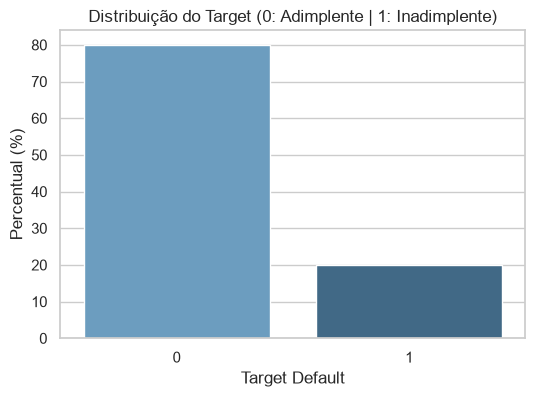

In [2]:
target_counts = df['target_default'].value_counts()
target_pct = df['target_default'].value_counts(normalize=True) * 100

summary_target = pd.DataFrame({'Qtd': target_counts, 'Percentual (%)': target_pct.round(2)})
print(summary_target)

plt.figure(figsize=(6, 4))
sns.barplot(x=target_pct.index, y=target_pct.values, palette="Blues_d")
plt.title("Distribuição do Target (0: Adimplente | 1: Inadimplente)")
plt.ylabel("Percentual (%)")
plt.xlabel("Target Default")
plt.show()

In [3]:
null_summary = df.isnull().sum()
null_summary = null_summary[null_summary > 0].sort_values(ascending=False)
null_pct = (null_summary / len(df)) * 100

df_null = pd.DataFrame({'Nulos': null_summary, 'Percentual (%)': null_pct.round(2)})
print("Variáveis com valores ausentes:")
print(df_null)

Variáveis com valores ausentes:
             Nulos  Percentual (%)
member_id   200000          100.00
emp_length   11603            5.80
revol_util     108            0.05
dti             69            0.03


In [4]:
df_feat = df.copy()

# Razão Valor do Empréstimo / Renda Anual
if 'loan_amnt' in df_feat.columns and 'annual_inc' in df_feat.columns:
    df_feat['loan_to_income'] = df_feat['loan_amnt'] / (df_feat['annual_inc'] + 1)

# Estimativa da Prestação Mensal sobre Renda Mensal
if 'installment' in df_feat.columns and 'annual_inc' in df_feat.columns:
    df_feat['installment_to_monthly_inc'] = df_feat['installment'] / ((df_feat['annual_inc'] / 12) + 1)

print("Novas features criadas com sucesso!")

Novas features criadas com sucesso!


In [ ]:
import optuna
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

X = df_feat.drop(columns=['target_default', 'member_id'], errors='ignore')
y = df_feat['target_default']

num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

preprocessor = ColumnTransformer([
    ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), num_cols),
    ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), cat_cols)
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)

# Função Objetivo do Optuna
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1.0, 5.0), 
        'random_state': 42,
        'verbose': -1
    }
    
    model = LGBMClassifier(**params)
    model.fit(X_train_prep, y_train)
    preds = model.predict_proba(X_test_prep)[:, 1]
    return roc_auc_score(y_test, preds)

# Executar otimização por 15 tentativas
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=15)

print(f"Melhor ROC-AUC encontrado: {study.best_value:.4f}")
print("Melhores hiperparâmetros:", study.best_params)

[I 2026-08-18 00:13:54,118] A new study created in memory with name: no-name-0df94b67-bb86-47b0-9450-4a2423b308ef
[I 2026-08-18 00:14:07,060] Trial 0 finished with value: 0.7084969044740012 and parameters: {'n_estimators': 487, 'max_depth': 10, 'learning_rate': 0.023562572991488385, 'num_leaves': 40, 'scale_pos_weight': 4.731924062325682}. Best is trial 0 with value: 0.7084969044740012.
[I 2026-08-18 00:14:11,983] Trial 1 finished with value: 0.708062652871964 and parameters: {'n_estimators': 460, 'max_depth': 7, 'learning_rate': 0.012723189953520418, 'num_leaves': 30, 'scale_pos_weight': 3.8506842224809827}. Best is trial 0 with value: 0.7084969044740012.
[I 2026-08-18 00:14:15,766] Trial 2 finished with value: 0.7091536884134966 and parameters: {'n_estimators': 462, 'max_depth': 6, 'learning_rate': 0.03651371218647373, 'num_leaves': 123, 'scale_pos_weight': 1.347357699664391}. Best is trial 2 with value: 0.7091536884134966.
[I 2026-08-18 00:14:18,173] Trial 3 finished with value: 0.7

🏆 Melhor ROC-AUC encontrado: 0.7094
Melhores hiperparâmetros: {'n_estimators': 398, 'max_depth': 5, 'learning_rate': 0.03900992955417133, 'num_leaves': 122, 'scale_pos_weight': 2.2076562722610182}
